In [61]:
# Import des paquets

import pandas as pd
import os
import load_data.donnees_chargement
from great_tables import GT


In [62]:
# Import des donnees

parite = load_data.donnees_chargement.load_parite()
parite.head()

/home/onyxia/work/Projet_python_2A/load_data/donnees_chargement.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  parite['week_day_number'] = parite['week_day'].replace({


,media_type,channel_code,channel_name,is_public_channel,date,week_day,school_holiday_zones,civil_holyday,hour,male_duration,female_duration,music_duration,week_day_number
636822,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,12,829.06,371.28,2056.80,5
636823,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,14,148.42,68.56,2993.40,5
636824,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,18,1722.84,307.90,1238.96,5
636825,tv,ART,ARTE,True,2010-01-01,Friday,ABC,True,21,2714.88,329.62,286.16,5
636826,tv,ART,ARTE,True,2010-01-02,Saturday,ABC,False,11,1254.78,1243.14,1070.86,6


In [63]:
# Calcul du temps de parole féminin et masculin par chaine

parite_chaine = parite.groupby('channel_code').agg(
    channel_name = ('channel_name', 'first'),
    female_duration = ('female_duration', 'sum'),
    male_duration = ('male_duration', 'sum')
).reset_index()

parite_chaine['proportion_female'] = parite_chaine['female_duration'] / (parite_chaine['female_duration'] + parite_chaine['male_duration'])

parite_chaine = parite_chaine.sort_values(by='proportion_female', ascending=False).reset_index()

In [64]:
# Affichage de la part de parole féminine par chaîne

(
    GT(parite_chaine[['channel_name', 'proportion_female']])
    .tab_header(
        title="Part du temps de parole féminin par chaîne",
        subtitle="De janvier 2010 à février 2019"
    )
    .fmt_percent(columns="proportion_female", decimals=0)
    .cols_label(
        channel_name = "Chaîne",
        proportion_female = "Part du temps de parole féminin"
    )
    .cols_width(cases={
        'channel_name': '70px',
        'proportion_female': '150px'
    })
    .tab_source_note("Source : INA")
)

GT(_tbl_data=  channel_name  proportion_female
0           M6           0.411471
1          TF1           0.364962
2     France 2           0.343634
3     France 3           0.318630
4         ARTE           0.291878, _body=<great_tables._gt_data.Body object at 0x7f0d514f96a0>, _boxhead=Boxhead([ColInfo(var='channel_name', type=<ColInfoTypeEnum.default: 1>, column_label='Chaîne', column_align='left', column_width='70px'), ColInfo(var='proportion_female', type=<ColInfoTypeEnum.default: 1>, column_label='Part du temps de parole féminin', column_align='right', column_width='150px')]), _stub=<great_tables._gt_data.Stub object at 0x7f0d4ed316d0>, _spanners=Spanners([]), _heading=Heading(title='Part du temps de parole féminin par chaîne', subtitle='De janvier 2010 à février 2019', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f0d514ebe10>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f0d4eee55b0>, _source_notes=['Source : INA'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f0d4ed33390>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f0d4ed32490>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='va

In [65]:
# Calcul du temps de parole masculin et fémnin par chaine et jour de la semaine


parite_jour_chaine = parite.groupby(['channel_code', 'week_day_number']).agg(
    week_day = ('week_day', 'first'),
    channel_name = ('channel_name', 'first'),
    female_duration = ('female_duration', 'sum'),
    male_duration = ('male_duration', 'sum')
).reset_index()

parite_jour_chaine['proportion_female'] = parite_jour_chaine['female_duration'] / (parite_jour_chaine['female_duration'] + parite_jour_chaine['male_duration'])

In [66]:
# Representation de la proportion de temps de parole féminin par jour de la semaine

def diagramme_temps_parole_jour(code_chaine):
    parite_jour = parite_jour_chaine[
        parite_jour_chaine['channel_code'] == code_chaine
    ].reset_index()
    diag = parite_jour.sort_values(by='week_day_number').plot.bar(
        x = 'week_day',
        y = 'proportion_female',
        title = "Temps de parole féminin par jour pour la chaîne " + parite_jour['channel_name'][0],
        legend=False,
        xlabel="Jour",
        ylabel="Part de temps de parole féminin",
        grid=True
    )
    
    diag.xaxis.grid(False)

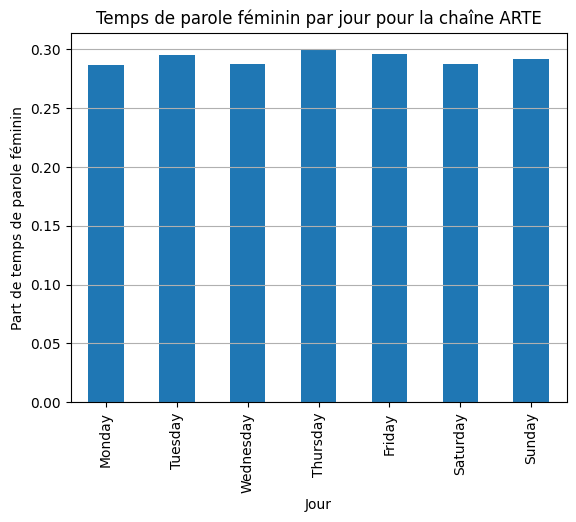

In [67]:
# Pour Arte : pas de différence entre les jours

diagramme_temps_parole_jour('ART')

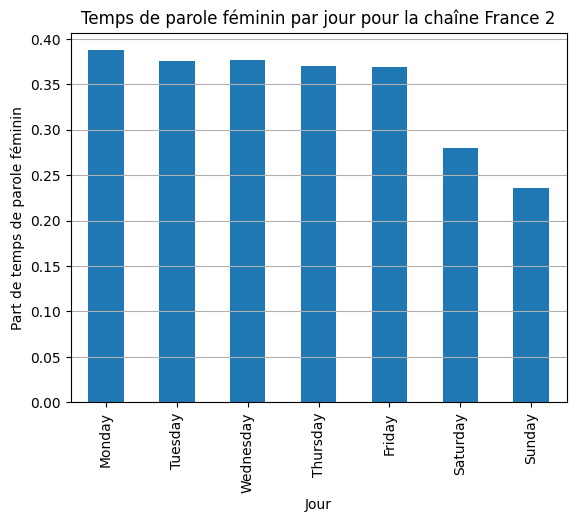

In [68]:
# Pour France 2 : décrochage de la part de parole féminine le week-end

diagramme_temps_parole_jour('FR2')

In [70]:
# Evolution du temps de parole féminin

parite['monthly_date'] = parite['date'].dt.to_period('M')

parite_evolution_chaine = parite.groupby(['monthly_date', 'channel_code']).agg(
    male_duration = ('male_duration', 'sum'),
    female_duration = ('female_duration', 'sum'),
    channel_name = ('channel_name', 'first')
).reset_index()

parite_evolution_chaine['proportion_female'] = parite_evolution_chaine['female_duration'] / (parite_evolution_chaine['female_duration'] + parite_evolution_chaine['male_duration'])

In [74]:
# Representation de l'évolution du temps de parole féminin, par chaine

def diagramme_temps_parole_evolution(code_chaine):
    parite_evolution = parite_evolution_chaine[
        parite_evolution_chaine['channel_code'] == code_chaine
    ].reset_index()

    diag = parite_evolution.set_index('monthly_date')['proportion_female'].plot(
        title = "Temps de parole féminin par mois pour la chaîne " + parite_evolution['channel_name'][0],
        legend=False,
        xlabel="Mois",
        ylabel="Part de temps de parole féminin",
    )

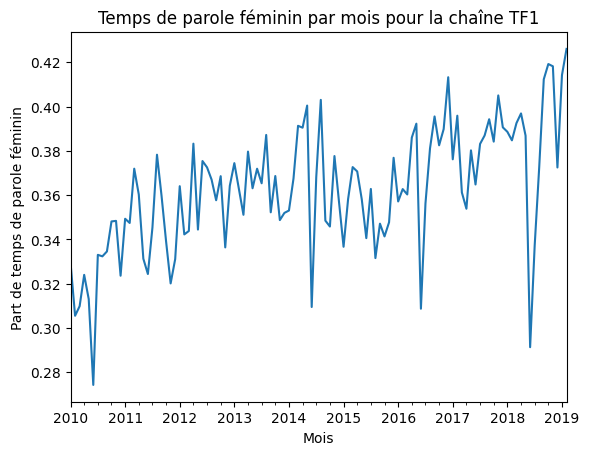

In [75]:
# TF1 : de gros trous : Coupe du Monde et Euro de football ?
diagramme_temps_parole_evolution('TF1')


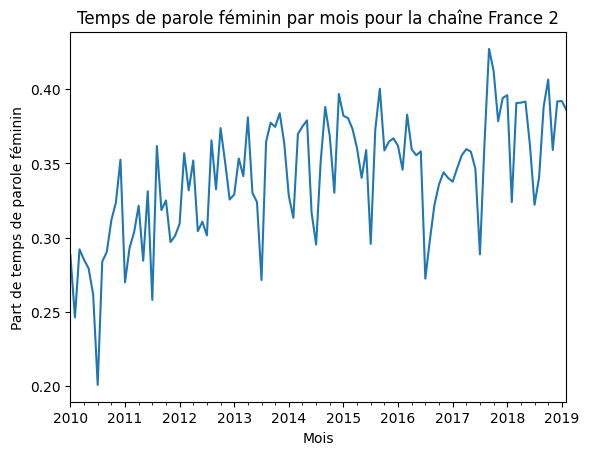

In [73]:
# France 2 : baisses récurrentes en été : Tour de France ?
diagramme_temps_parole_evolution('FR2')

In [78]:
# Temps de parole féminin par mois de l'année

parite['year_month_number'] = parite['date'].dt.month

parite_mois_chaine = parite.groupby(['channel_code', 'year_month_number']).agg(
    channel_name = ('channel_name', 'first'),
    female_duration = ('female_duration', 'sum'),
    male_duration = ('male_duration', 'sum')
).reset_index()

parite_mois_chaine['proportion_female'] = parite_mois_chaine['female_duration'] / (parite_mois_chaine['female_duration'] + parite_mois_chaine['male_duration'])

parite_mois_chaine.head()

,channel_code,year_month_number,channel_name,female_duration,male_duration,proportion_female
0,ART,1,ARTE,1319413.44,3135922.40,0.296142
1,ART,2,ARTE,1192270.50,2877588.24,0.292951
2,ART,3,ARTE,976119.84,2359367.58,0.292647
3,ART,4,ARTE,975913.20,2292546.76,0.298585
4,ART,5,ARTE,1061048.48,2475235.42,0.300046


In [93]:
# Representation de la proportion de temps de parole féminin par mois de l'année

def diagramme_temps_parole_mois(code_chaine):
    parite_mois = parite_mois_chaine[
        parite_mois_chaine['channel_code'] == code_chaine
    ].reset_index()
    diag = parite_mois.sort_values(by='year_month_number').plot.bar(
        x = 'year_month_number',
        y = 'proportion_female',
        title = "Temps de parole féminin par mois pour la chaîne " + parite_mois['channel_name'][0],
        legend=False,
        xlabel="Mois",
        ylabel="Part de temps de parole féminin",
        grid=True
    )
    
    diag.xaxis.grid(False)

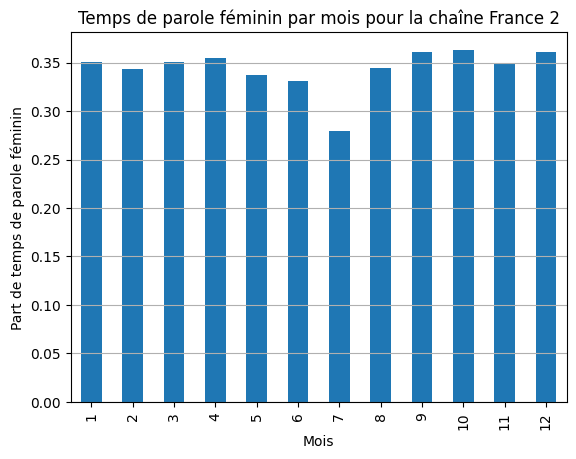

In [101]:
# France 2 : décrochage en juillet (Tour de France)
diagramme_temps_parole_mois('FR2')

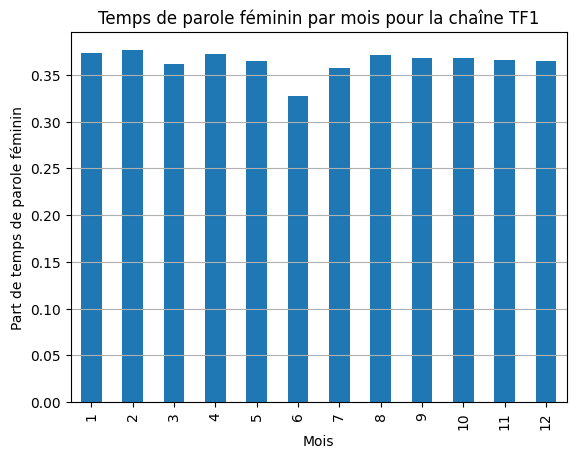

In [102]:
# TF1 : décrochage en juin (compétitions de football)
diagramme_temps_parole_mois('TF1')

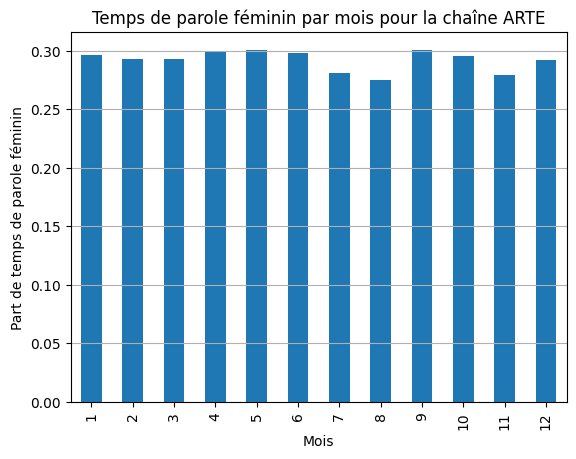

In [104]:
# ARTE : RAS
diagramme_temps_parole_mois('ART')